# Test Technique : Prédiction de la Demande Ferroviaire

**Objectif :** Construire un modèle prédictif robuste pour estimer la demande non contrainte des trains. 

Dans un contexte de Revenue Management, la prévision de la demande est le pilier central de l'optimisation tarifaire. Avant de modéliser, cette analyse exploratoire vise à valider la cohérence des données et à identifier les dynamiques d'achat (Booking Curve, élasticité-prix, saisonnalité, cannibalisation) afin de guider notre stratégie de Feature Engineering.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import timedelta

# Configuration globale pour la lisibilité des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Chargement des données
train = pd.read_parquet('./data/cayzn_train.parquet')
test = pd.read_parquet('./data/cayzn_test.parquet')

print(f"Dimensions du dataset d'entraînement : {train.shape}")
display(train.head())

Dimensions du dataset d'entraînement : (632841, 30)


,demand,departure_date,destination_current_public_holiday,destination_current_school_holiday,destination_days_to_next_public_holiday,destination_days_to_next_school_holiday,destination_station_name,od_destination_time,od_number_of_similar_12_hours,od_number_of_similar_2_hours,...,origin_days_to_next_school_holiday,origin_station_name,price,sale_date,sale_day,sale_day_x,sale_month,sale_week,sale_weekday,sale_year
0,1,2019-03-01,0,1,52,-13,ag,1088,5,1,...,-6,cpe,26.65,2018-12-02,2,-89,12,6,6,2018
1,6,2019-03-01,0,1,52,-13,ag,1088,5,1,...,-6,cpe,26.65,2018-12-03,3,-88,12,0,0,2018
2,5,2019-03-01,0,1,52,-13,ag,1088,5,1,...,-6,cpe,26.65,2018-12-04,4,-87,12,1,1,2018
3,0,2019-03-01,0,1,52,-13,ag,1088,5,1,...,-6,cpe,26.65,2018-12-05,5,-86,12,2,2,2018
4,0,2019-03-01,0,1,52,-13,ag,1088,5,1,...,-6,cpe,26.65,2018-12-06,6,-85,12,3,3,2018


## 1. Analyse Exploratoire des Données (EDA)
### 1.1. La Variable Cible et la Booking Curve
En transport, la demande n'est pas linéaire dans le temps. On s'attend à observer une accélération exponentielle à l'approche du départ.

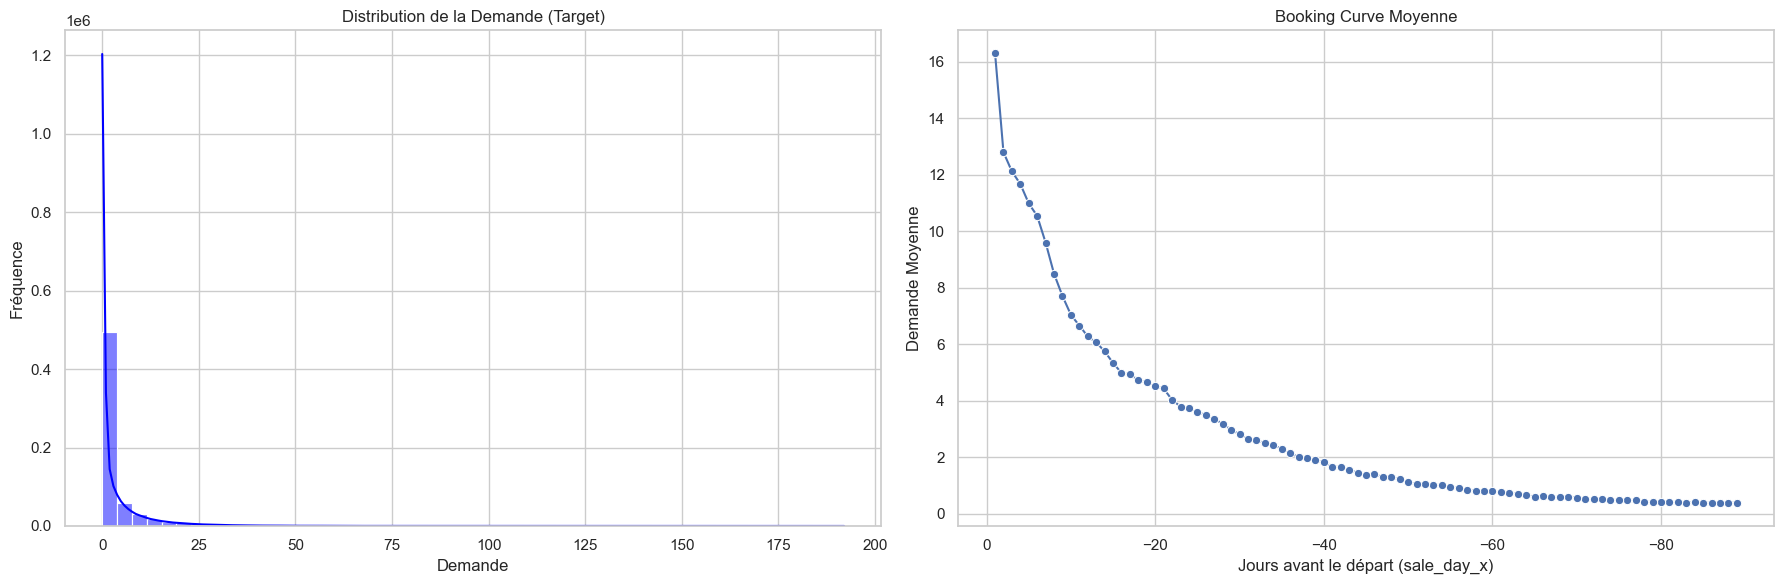

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Distribution de la demande
sns.histplot(train['demand'], bins=50, kde=True, color='blue', ax=axes[0])
axes[0].set_title("Distribution de la Demande (Target)")
axes[0].set_xlabel("Demande")
axes[0].set_ylabel("Fréquence")

# La Booking Curve (Demande moyenne selon le jour avant départ)
booking_curve = train.groupby('sale_day_x')['demand'].mean().reset_index()
sns.lineplot(data=booking_curve, x='sale_day_x', y='demand', marker="o", ax=axes[1])
axes[1].set_title("Booking Curve Moyenne")
axes[1].set_xlabel("Jours avant le départ (sale_day_x)")
axes[1].set_ylabel("Demande Moyenne")
axes[1].invert_xaxis() # Lecture de gauche à droite (approche du départ)

plt.tight_layout()
plt.show()

# Observation : La relation est fortement non-linéaire. Les modèles arborescents (LightGBM/CatBoost) 
# seront plus adaptés qu'une régression linéaire basique.

### 1.2. Dynamique Tarifaire et Élasticité-Prix
Le prix n'est pas une simple variable explicative, c'est la variable de contrôle du Yield Manager. Il faut analyser son évolution moyenne, mais surtout sa dispersion (variance) à la dernière minute.

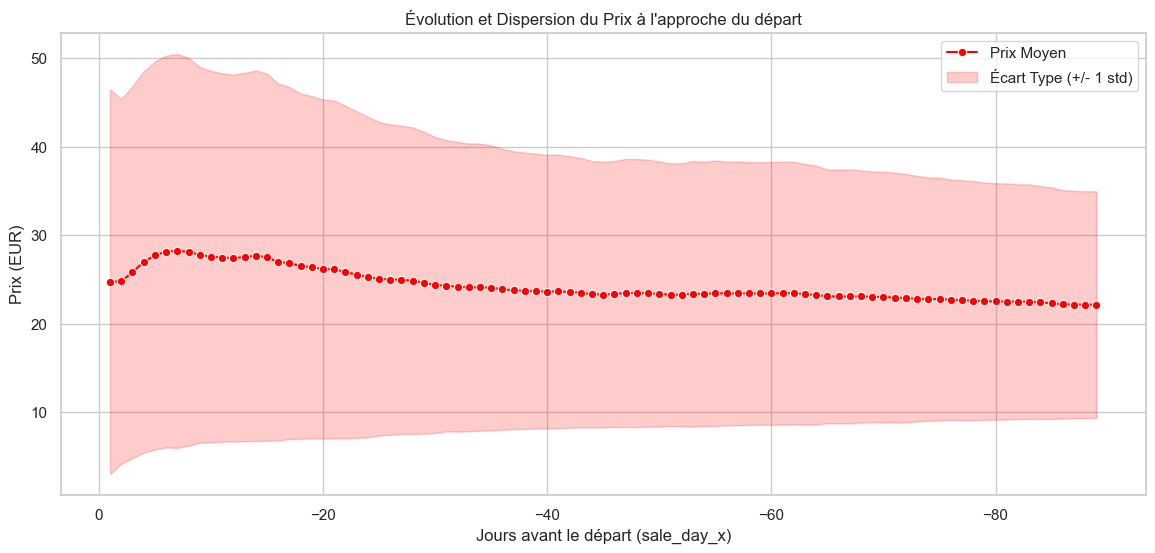

In [5]:
plt.figure(figsize=(14, 6))

# Calcul de la moyenne et de l'écart type des prix selon l'horizon de vente
price_stats = train.groupby('sale_day_x')['price'].agg(['mean', 'std']).reset_index()

sns.lineplot(data=price_stats, x='sale_day_x', y='mean', color='red', marker="o", label='Prix Moyen')
plt.fill_between(price_stats['sale_day_x'],
                 price_stats['mean'] - price_stats['std'],
                 price_stats['mean'] + price_stats['std'],
                 color='red', alpha=0.2, label='Écart Type (+/- 1 std)')

plt.title("Évolution et Dispersion du Prix à l'approche du départ")
plt.xlabel("Jours avant le départ (sale_day_x)")
plt.ylabel("Prix (EUR)")
plt.gca().invert_xaxis()
plt.legend()
plt.show()

# Observation métier critique : À l'approche du départ, l'écart-type explose.
# Le prix moyen stagne car le système polarise : il brade les trains vides et vend à prix fort les trains pleins.
# Le modèle aura besoin du contexte (prix relatif) et non du prix absolu pour comprendre si l'offre est compétitive.

### 1.3. Saisonnalité et Impacts Exogènes
La demande ferroviaire est rythmée par le calendrier (week-ends, jours fériés) et la concurrence inter-trains.

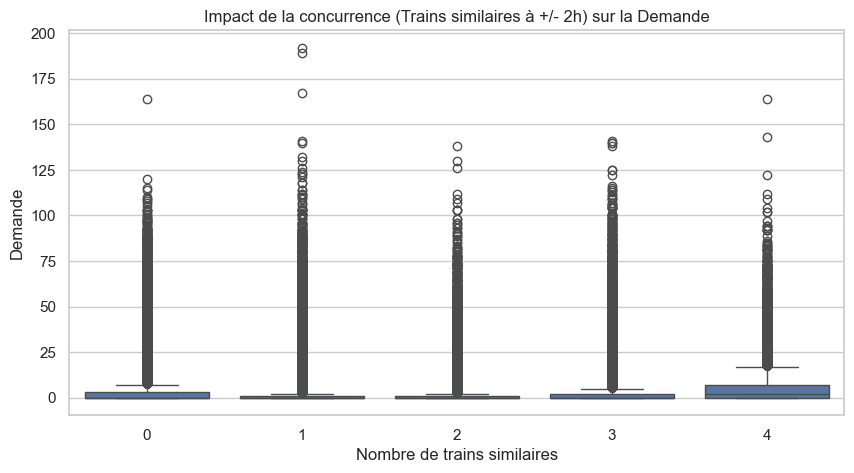

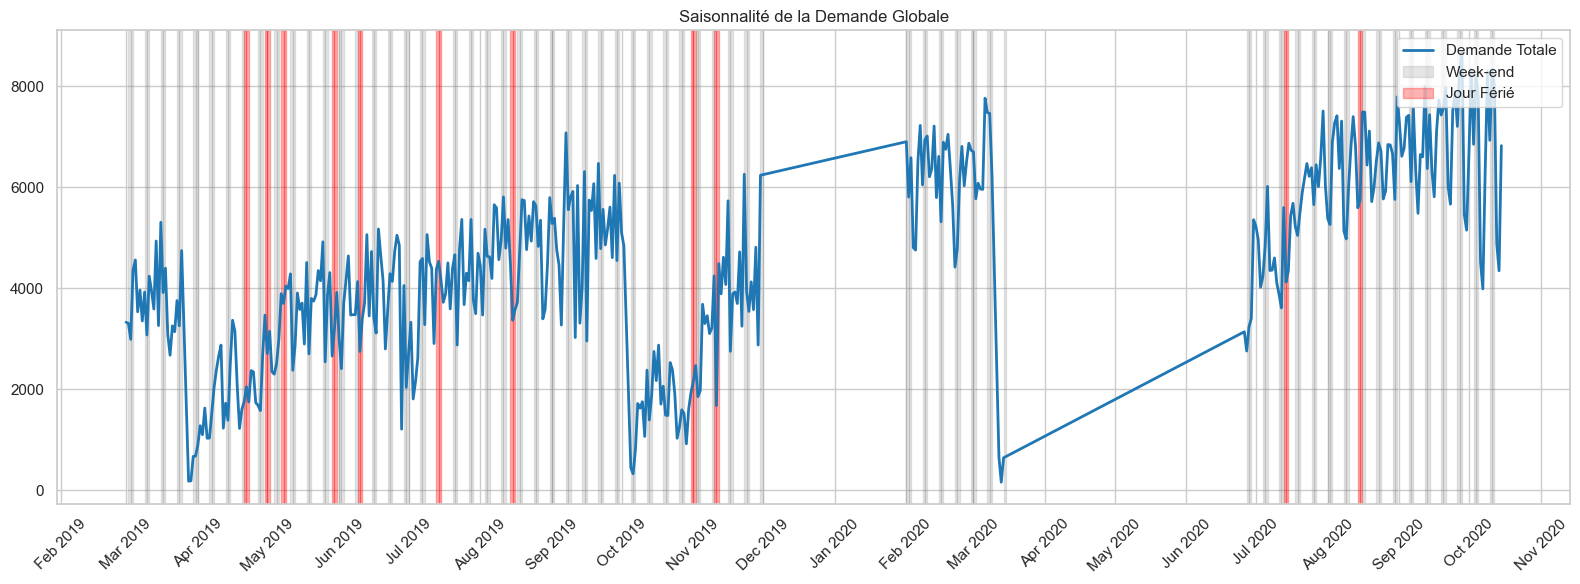

In [6]:
# 1. Impact de la concurrence interne (cannibalisation)
plt.figure(figsize=(10, 5))
sim_trains_df = train[train['od_number_of_similar_2_hours'] != -1]
sns.boxplot(data=sim_trains_df, x='od_number_of_similar_2_hours', y='demand')
plt.title("Impact de la concurrence (Trains similaires à +/- 2h) sur la Demande")
plt.xlabel("Nombre de trains similaires")
plt.ylabel("Demande")
plt.show()

# 2. Saisonnalité macroscopique (Jours fériés et Week-ends)
train['departure_date'] = pd.to_datetime(train['departure_date'])

daily_seasonality = train.groupby('departure_date').agg(
    total_demand=('demand', 'sum'),
    holiday_origin=('origin_current_public_holiday', 'max'),
    holiday_dest=('destination_current_public_holiday', 'max'),
    weekday=('od_origin_weekday', 'max')
).reset_index()

daily_seasonality['is_holiday'] = (daily_seasonality['holiday_origin'] == 1) | (daily_seasonality['holiday_dest'] == 1)
daily_seasonality['is_weekend'] = daily_seasonality['weekday'].isin([5, 6])

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily_seasonality['departure_date'], daily_seasonality['total_demand'], color='#1f77b4', linewidth=2, label='Demande Totale')

added_holiday, added_weekend = False, False
for _, row in daily_seasonality.iterrows():
    start_date = row['departure_date']
    end_date = start_date + pd.Timedelta(days=1)
    if row['is_holiday']:
        ax.axvspan(start_date, end_date, color='red', alpha=0.3, label='Jour Férié' if not added_holiday else "")
        added_holiday = True
    elif row['is_weekend']:
        ax.axvspan(start_date, end_date, color='gray', alpha=0.2, label='Week-end' if not added_weekend else "")
        added_weekend = True

ax.set_title("Saisonnalité de la Demande Globale")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Attention : Le trou de données brutal début 2020 et la chute au printemps nécessitent une inspection de la qualité des données.

## 2. Audit de la Qualité des Données (Détection de Gaps)
Afin d'éviter d'apprendre des biais structurels à notre modèle, nous devons identifier les périodes d'arrêt de service (ex: grèves, confinements COVID-19).

In [7]:
def detect_data_gaps(df, date_column='departure_date'):
    existing_dates = df[date_column].dt.date.dropna().unique()
    if len(existing_dates) == 0:
        return
        
    full_calendar = pd.date_range(start=existing_dates.min(), end=existing_dates.max()).date
    missing_dates = sorted(list(set(full_calendar) - set(existing_dates)))
    
    if not missing_dates:
        print("Aucun trou de données détecté.")
        return
        
    gaps, start_gap, prev_date = [], missing_dates[0], missing_dates[0]
    for current_date in missing_dates[1:]:
        if (current_date - prev_date).days > 1:
            gaps.append((start_gap, prev_date))
            start_gap = current_date
        prev_date = current_date
    gaps.append((start_gap, prev_date))
    
    print("--- PÉRIODES MANQUANTES DÉTECTÉES ---")
    for start, end in gaps:
        print(f"Du {start} au {end} : {(end - start).days + 1} jours manquants")

detect_data_gaps(train)

# Les résultats confirment l'impact des grèves SNCF (Déc 2019 - Janv 2020) et du premier confinement COVID-19.

--- PÉRIODES MANQUANTES DÉTECTÉES ---
Du 2019-03-26 au 2019-03-27 : 2 jours manquants
Du 2019-10-03 au 2019-10-04 : 2 jours manquants
Du 2019-12-01 au 2020-01-31 : 62 jours manquants
Du 2020-03-10 au 2020-03-11 : 2 jours manquants
Du 2020-03-15 au 2020-06-25 : 103 jours manquants


## 3. Feature Engineering
Notre stratégie est de s'appuyer exclusivement sur les données internes pour maximiser la robustesse en production. Nous allons créer des features métier basées sur les principes du Revenue Management.

In [8]:
def feature_engineering_pipeline(df):
    print("Démarrage du Feature Engineering...")
    df_fe = df.copy()
    df_fe['departure_date'] = pd.to_datetime(df_fe['departure_date'])
    
    # ---------------------------------------------------------
    # 1. FLAG ANOMALIES (Basé sur l'audit de qualité)
    # ---------------------------------------------------------
    conditions = [
        df_fe['departure_date'].between('2019-10-03', '2019-10-04'),
        df_fe['departure_date'].between('2019-12-01', '2020-01-31'), # Grèves
        df_fe['departure_date'].between('2020-03-10', '2020-03-11'),
        df_fe['departure_date'].between('2020-03-15', '2020-06-25')  # Confinement
    ]
    df_fe['is_off_service'] = np.where(np.logical_or.reduce(conditions), 0, 1)

    # ---------------------------------------------------------
    # 2. PRÉREQUIS : Tri chronologique pour éviter la fuite de données (Data Leakage)
    # ---------------------------------------------------------
    if 'Unique_Train_ID' not in df_fe.columns:
        df_fe['Unique_Train_ID'] = df_fe['departure_date'].astype(str) + "_" + \
                                   df_fe['od_origin_time'].astype(str) + "_" + \
                                   df_fe['origin_station_name'] + "_" + \
                                   df_fe['destination_station_name']
                                   
    df_fe = df_fe.sort_values(by=['Unique_Train_ID', 'sale_day_x']).reset_index(drop=True)

    # ---------------------------------------------------------
    # 3. COMPORTEMENT D'ACHAT (Temporal Binning)
    # ---------------------------------------------------------
    # Profilage de la clientèle en fonction de la maturité du vol/train
    df_fe['is_last_minute'] = np.where(df_fe['sale_day_x'] >= -3, 1, 0)
    df_fe['is_early_bird'] = np.where(df_fe['sale_day_x'] <= -60, 1, 0)

    # ---------------------------------------------------------
    # 4. CONTEXTUALISATION DU PRIX (L'offre est-elle attractive ?)
    # ---------------------------------------------------------
    # Prix moyen pour l'OD spécifique *à ce jour de la semaine* 
    df_fe['od_weekday_mean_price'] = df_fe.groupby([
        'origin_station_name', 'destination_station_name', 'od_origin_weekday'
    ])['price'].transform('mean')

    # Ratio d'attractivité (>1 = cher, <1 = bonne affaire)
    df_fe['price_ratio_to_od_weekday_mean'] = df_fe['price'] / (df_fe['od_weekday_mean_price'] + 0.001)

    # Limites historiques de prix pour la ligne courante (jusqu'au jour de vente)
    df_fe['max_price_seen_so_far'] = df_fe.groupby('Unique_Train_ID')['price'].cummax()
    df_fe['min_price_seen_so_far'] = df_fe.groupby('Unique_Train_ID')['price'].cummin()

    # ---------------------------------------------------------
    # 5. PUISSANCE DE LIGNE ET VÉLOCITÉ (Momentum)
    # ---------------------------------------------------------
    # Fréquence totale de l'OD sur la journée de départ
    df_fe['daily_od_frequency'] = df_fe.groupby([
        'departure_date', 'origin_station_name', 'destination_station_name'
    ])['Unique_Train_ID'].transform('nunique')

    # Vélocité des ventes : Moyenne glissante sur 7 jours (shift(1) est crucial ici)
    df_fe['demand_rolling_avg_7d'] = df_fe.groupby('Unique_Train_ID')['demand'] \
                                          .shift(1) \
                                          .rolling(window=7, min_periods=1) \
                                          .mean() \
                                          .fillna(0)

    print(f"Feature Engineering terminé. Dimensions : {df_fe.shape}")
    return df_fe

# Application au dataset d'entraînement
train_fe = feature_engineering_pipeline(train)

# Vérification des nouvelles variables
cols_check = ['Unique_Train_ID', 'sale_day_x', 'price', 'price_ratio_to_od_weekday_mean', 
              'demand', 'demand_rolling_avg_7d', 'is_last_minute']
display(train_fe[cols_check].head(15))

Démarrage du Feature Engineering...
Feature Engineering terminé. Dimensions : (632841, 40)


,Unique_Train_ID,sale_day_x,price,price_ratio_to_od_weekday_mean,demand,demand_rolling_avg_7d,is_last_minute
0,2019-03-01_1006_bb_cgm,-89,11.65,0.612317,0,0.0,0
1,2019-03-01_1006_bb_cgm,-88,11.65,0.612317,0,0.0,0
2,2019-03-01_1006_bb_cgm,-87,11.65,0.612317,0,0.0,0
3,2019-03-01_1006_bb_cgm,-86,11.65,0.612317,0,0.0,0
4,2019-03-01_1006_bb_cgm,-85,11.65,0.612317,0,0.0,0
5,2019-03-01_1006_bb_cgm,-84,11.65,0.612317,0,0.0,0
6,2019-03-01_1006_bb_cgm,-83,11.65,0.612317,0,0.0,0
7,2019-03-01_1006_bb_cgm,-82,11.65,0.612317,0,0.0,0
8,2019-03-01_1006_bb_cgm,-81,11.65,0.612317,0,0.0,0
9,2019-03-01_1006_bb_cgm,-80,11.65,0.612317,0,0.0,0


### Prochaine étape envisagée :
Le dataset est maintenant enrichi de variables temporelles et métier. Du fait de la forte présence de variables catégorielles (noms de gares) et de la nature non linéaire de la demande de dernière minute, **CatBoost** s'impose comme l'algorithme de référence pour l'étape de modélisation (gestion native du *Target Encoding* via les Ordered Target Statistics).

## 4. Stratégie de Validation et Modélisation

### 4.1. Séparation Temporelle (Out-of-Time Split)
Pour un problème de prévision de la demande (Séries Temporelles / Revenue Management), un split aléatoire (ex: `train_test_split` de sklearn) provoquerait une fuite de données majeure (Data Leakage) : le modèle utiliserait des données du futur pour prédire le passé. 
Nous devons séparer les données chronologiquement, en utilisant par exemple les 85% de dates de départ les plus anciennes pour l'entraînement, et les 15% les plus récentes pour la validation.

In [9]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Définition des features
target = 'demand'
cat_features = ['origin_station_name', 'destination_station_name']

# On exclut les identifiants, dates brutes et la target de nos variables explicatives
features = [col for col in train_fe.columns if col not in [
    'demand', 'departure_date', 'sale_date', 'Unique_Train_ID'
]]

# Conversion des catégories en string (recommandé pour CatBoost)
for col in cat_features:
    train_fe[col] = train_fe[col].astype(str)

# Séparation Temporelle (Split à environ 85% des données chronologiques)
# On trie le dataset par date de départ pour être sûr
train_fe = train_fe.sort_values('departure_date')
split_index = int(len(train_fe) * 0.85)
split_date = train_fe.iloc[split_index]['departure_date']

print(f"Date de coupure (Train/Val Split) : {split_date.date()}")

X_train = train_fe[train_fe['departure_date'] < split_date][features]
y_train = train_fe[train_fe['departure_date'] < split_date][target]

X_val = train_fe[train_fe['departure_date'] >= split_date][features]
y_val = train_fe[train_fe['departure_date'] >= split_date][target]

print(f"Taille Train : {X_train.shape[0]} lignes | Taille Val : {X_val.shape[0]} lignes")

Date de coupure (Train/Val Split) : 2020-09-10
Taille Train : 537347 lignes | Taille Val : 95494 lignes


### 4.2. Entraînement du Modèle CatBoost
CatBoost est sélectionné pour sa gestion native et très performante des variables catégorielles (Target Statistics) sans nécessiter de One-Hot Encoding ou de Target Encoding manuel, évitant ainsi le risque de surapprentissage sur les noms de gares.

In [10]:
# Initialisation du modèle
model_cb = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='MAE', # Optimisation directe sur l'erreur absolue (impact business)
    eval_metric='MAE',
    cat_features=cat_features,
    random_seed=42,
    verbose=100
)

# Entraînement avec Early Stopping pour prévenir l'overfitting
print("Début de l'entraînement...")
model_cb.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    use_best_model=True
)

# Évaluation globale
y_pred = model_cb.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print("\n--- PERFORMANCES SUR LE SET DE VALIDATION ---")
print(f"MAE (Mean Absolute Error) : {mae:.2f} billets")
print(f"RMSE (Root Mean Squared Error) : {rmse:.2f} billets")

Début de l'entraînement...
0:	learn: 2.9751929	test: 2.5007617	best: 2.5007617 (0)	total: 851ms	remaining: 14m 10s
100:	learn: 1.3894217	test: 1.1632610	best: 1.1632610 (100)	total: 59.5s	remaining: 8m 49s
200:	learn: 1.3599473	test: 1.1492693	best: 1.1492542 (199)	total: 1m 50s	remaining: 7m 20s
300:	learn: 1.3472421	test: 1.1461450	best: 1.1461450 (300)	total: 2m 33s	remaining: 5m 57s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.145285856
bestIteration = 313

Shrink model to first 314 iterations.

--- PERFORMANCES SUR LE SET DE VALIDATION ---
MAE (Mean Absolute Error) : 1.15 billets
RMSE (Root Mean Squared Error) : 2.93 billets


## 5. Model Validation & Analyse des Erreurs (Test Set)

Jusqu'à présent, nous avons optimisé le modèle sur l'erreur absolue de la demande (MAE). Cependant, notre objectif final de Revenue Management est d'optimiser le revenu ($Prix \times Demande$). 

Une erreur de prévision de 3 billets sur un tarif à 15€ a un impact financier de 45€. La même erreur sur un tarif à 100€ a un impact de 300€. 
Nous allons donc évaluer notre modèle sur le jeu de test non pas seulement sur la justesse du volume (Demande), mais sur la justesse du Revenu estimé, en agrégeant les erreurs à différents niveaux stratégiques.

In [13]:
# 1. Application du pipeline de Feature Engineering sur le set de TEST
test_fe = feature_engineering_pipeline(test)

# S'assurer que les variables catégorielles sont bien en string pour CatBoost
for col in cat_features:
    test_fe[col] = test_fe[col].astype(str)

# 2. Préparation des données de test
X_test = test_fe[features]
y_test = test_fe[target]

# 3. Prédictions
y_pred_test = model_cb.predict(X_test)
y_pred_test = np.maximum(0, y_pred_test)  # On tronque à 0 (une demande négative n'existe pas)

# 4. Création des métriques d'erreur dans le dataframe pour l'analyse
test_fe['predicted_demand'] = y_pred_test
test_fe['demand_error'] = test_fe['predicted_demand'] - test_fe['demand']
test_fe['demand_abs_error'] = test_fe['demand_error'].abs()

# Création des métriques orientées Business (REVENU)
test_fe['true_revenue'] = test_fe['demand'] * test_fe['price']
test_fe['predicted_revenue'] = test_fe['predicted_demand'] * test_fe['price']
test_fe['revenue_abs_error'] = (test_fe['predicted_revenue'] - test_fe['true_revenue']).abs()

print("--- PERFORMANCES GLOBALES SUR LE SET DE TEST ---")
print(f"MAE Demande (Volume) : {test_fe['demand_abs_error'].mean():.2f} billets par prédiction")
print(f"MAE Revenu (Impact Financier) : {test_fe['revenue_abs_error'].mean():.2f} € par prédiction")

Démarrage du Feature Engineering...
Feature Engineering terminé. Dimensions : (32565, 40)
--- PERFORMANCES GLOBALES SUR LE SET DE TEST ---
MAE Demande (Volume) : 1.53 billets par prédiction
MAE Revenu (Impact Financier) : 49.73 € par prédiction


### 5.1. Analyse des erreurs par Horizon de vente (`sale_day_x`)
Le comportement d'achat change drastiquement à la dernière minute. Le modèle est-il aussi performant à J-90 qu'à J-1 ?

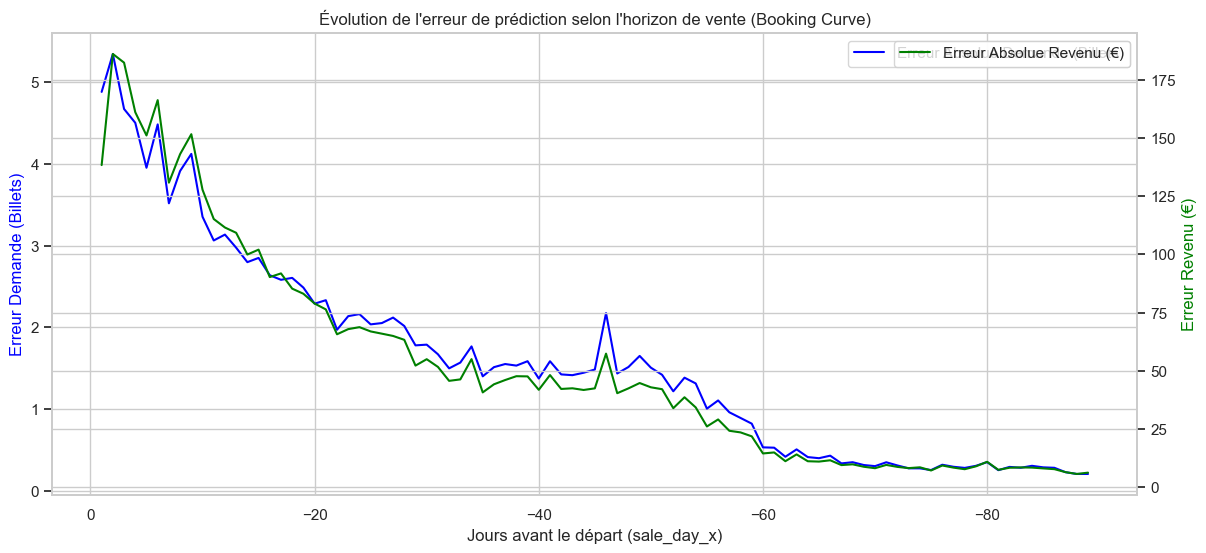

In [17]:
plt.figure(figsize=(14, 6))

# Calcul de l'erreur absolue moyenne par jour avant le départ
error_by_day_x = test_fe.groupby('sale_day_x').agg(
    mean_demand_error=('demand_abs_error', 'mean'),
    mean_revenue_error=('revenue_abs_error', 'mean')
).reset_index()

ax1 = sns.lineplot(data=error_by_day_x, x='sale_day_x', y='mean_demand_error', color='blue', label='Erreur Absolue Demande (Billets)')
ax1.set_ylabel('Erreur Demande (Billets)', color='blue')

# Ajout d'un axe secondaire pour le revenu
ax2 = ax1.twinx()
sns.lineplot(data=error_by_day_x, x='sale_day_x', y='mean_revenue_error', color='green', label='Erreur Absolue Revenu (€)', ax=ax2)
ax2.set_ylabel('Erreur Revenu (€)', color='green')

plt.title("Évolution de l'erreur de prédiction selon l'horizon de vente (Booking Curve)")
ax1.set_xlabel("Jours avant le départ (sale_day_x)")
ax1.invert_xaxis()
plt.show()

# INTERPRÉTATION :
# Généralement, l'erreur explose à J-10 car c'est là que la variance de la demande est la plus forte.
# Si l'erreur en revenu monte beaucoup plus vite que l'erreur en volume, cela signifie que notre modèle 
# se trompe particulièrement lorsque les billets sont les plus chers (dernière minute).

### 5.2. Analyse des erreurs par Trajet (OD level)
Certaines lignes sont structurellement plus difficiles à prédire (ex: lignes très touristiques avec beaucoup de volatilité vs lignes régulières de commuters).

C:\Users\amind\AppData\Local\Temp\ipykernel_34280\2176241201.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=worst_ods['mean_revenue_error'], y=worst_ods.index, palette='Reds_r')


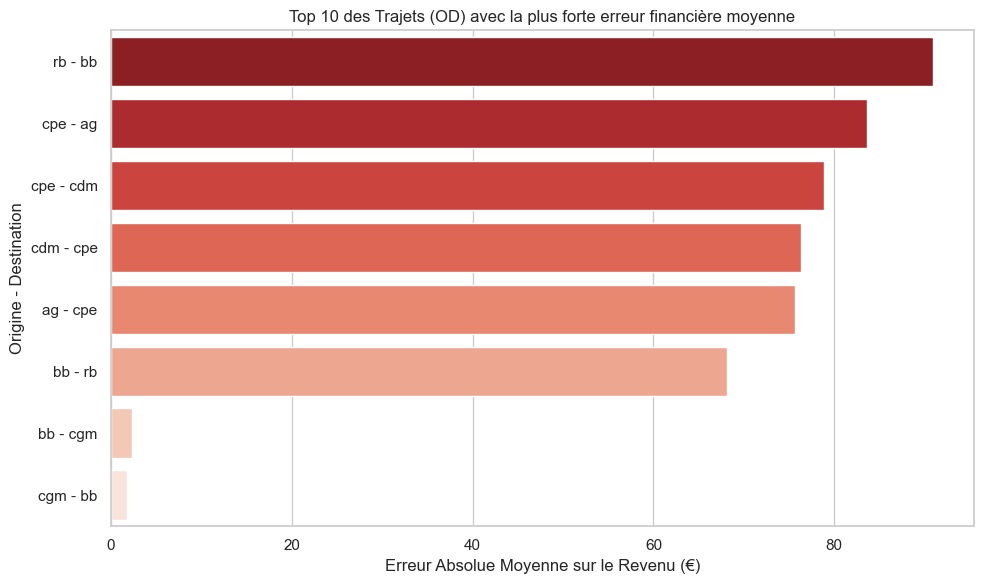

In [18]:
test_fe['OD'] = test_fe['origin_station_name'] + " - " + test_fe['destination_station_name']

# Calcul de l'erreur par ligne et sélection des 10 lignes générant le plus grand risque financier
error_by_od = test_fe.groupby('OD').agg(
    mean_revenue_error=('revenue_abs_error', 'mean'),
    mean_demand=('demand', 'mean'),
    prediction_count=('demand', 'count')
).sort_values(by='mean_revenue_error', ascending=False)

# On filtre les OD marginaux (moins de 50 prédictions) pour se concentrer sur les flux principaux
worst_ods = error_by_od[error_by_od['prediction_count'] > 50].head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=worst_ods['mean_revenue_error'], y=worst_ods.index, palette='Reds_r')
plt.title("Top 10 des Trajets (OD) avec la plus forte erreur financière moyenne")
plt.xlabel("Erreur Absolue Moyenne sur le Revenu (€)")
plt.ylabel("Origine - Destination")
plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# Ces trajets nécessitent probablement des features dédiées (ex: événements locaux, météo sur la destination touristique)
# ou un modèle entraîné spécifiquement pour eux s'ils ont un comportement atypique.

### 5.3. Analyse de l'erreur par Paliers de Prix (Sensibilité Tarifaire)
Puisque le but est d'optimiser le revenu, nous devons vérifier si notre modèle sous-performe lorsque nous proposons des billets à des tarifs élevés. Un modèle qui prédit bien les promos mais mal les billets plein tarif est dangereux pour l'entreprise.

C:\Users\amind\AppData\Local\Temp\ipykernel_34280\2377506311.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_by_price, x='price_tier', y='bias_demand', ax=axes[0], palette='coolwarm')
C:\Users\amind\AppData\Local\Temp\ipykernel_34280\2377506311.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_by_price, x='price_tier', y='mae_revenue', ax=axes[1], palette='Oranges')


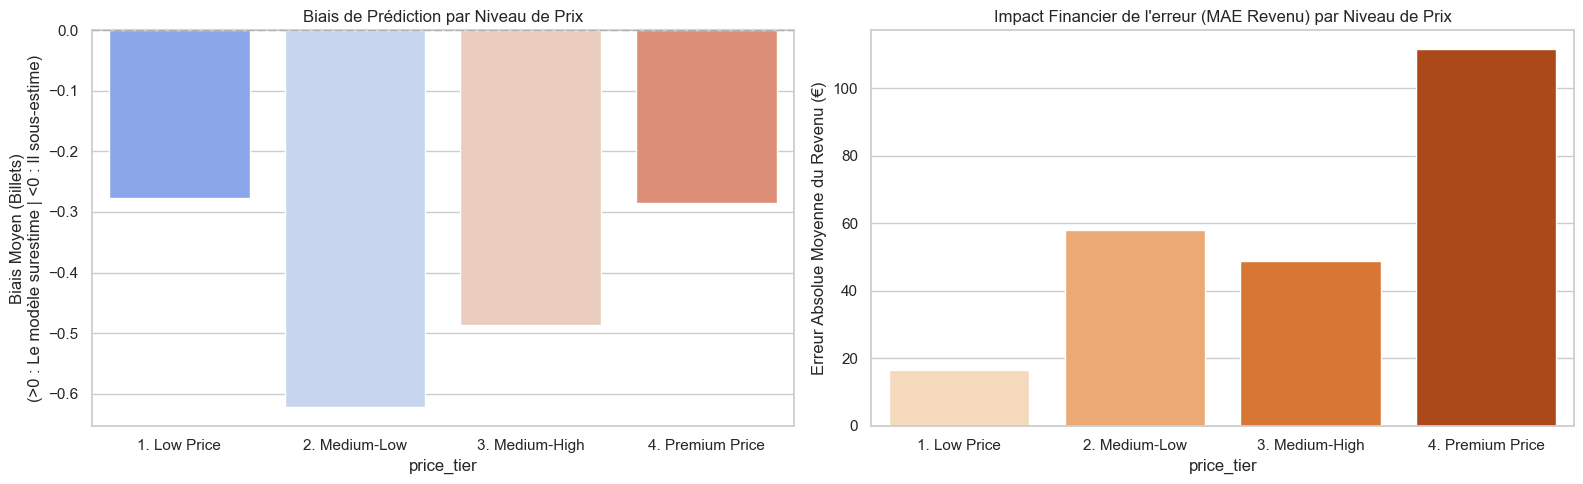

In [19]:
# Création de 4 catégories de prix (Quartiles) pour l'analyse
test_fe['price_tier'] = pd.qcut(test_fe['price'], q=4, labels=['1. Low Price', '2. Medium-Low', '3. Medium-High', '4. Premium Price'])

error_by_price = test_fe.groupby('price_tier').agg(
    bias_demand=('demand_error', 'mean'),       # Biais : est-ce qu'on surestime (+) ou sous-estime (-) ?
    mae_revenue=('revenue_abs_error', 'mean')   # Ampleur de l'erreur financière
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graphique 1 : Le Biais (Surestimation vs Sous-estimation)
sns.barplot(data=error_by_price, x='price_tier', y='bias_demand', ax=axes[0], palette='coolwarm')
axes[0].set_title("Biais de Prédiction par Niveau de Prix")
axes[0].set_ylabel("Biais Moyen (Billets)\n(>0 : Le modèle surestime | <0 : Il sous-estime)")
axes[0].axhline(0, color='black', linestyle='--')

# Graphique 2 : L'impact financier direct
sns.barplot(data=error_by_price, x='price_tier', y='mae_revenue', ax=axes[1], palette='Oranges')
axes[1].set_title("Impact Financier de l'erreur (MAE Revenu) par Niveau de Prix")
axes[1].set_ylabel("Erreur Absolue Moyenne du Revenu (€)")

plt.tight_layout()
plt.show()

# INTERPRÉTATION :
# Le graphique de gauche (Biais) est fondamental. S'il est très négatif pour la catégorie 'Premium',
# cela signifie que notre algorithme pense que personne n'achètera à ce prix-là, alors que les gens achètent.
# Cela pousserait le Yield Manager à baisser ses prix à tort, détruisant ainsi la rentabilité du train.